In [3]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# To save the model
import joblib

#downloaded important nlp resources to use libraries
nltk.download('punkt') #for tokenization
nltk.download('punkt_tab')
nltk.download('stopwords') # for seeing the common data (not useful one)
nltk.download('wordnet') # for lemmatization

# Imported libraries for data handling (pandas, numpy), text preprocessing (nltk),
# machine learning (sklearn) to split (train test, import the model etc).
# visualization (matplotlib, seaborn, wordcloud),
# and saving trained models (joblib)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
#Load the Amazon Reviews Dataset:

df = pd.read_csv("/content/Reviews.csv")
df.head()

#load the dataset and showed first 5 rows.

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.info()
df.isnull().sum()


#checking for missing values and the datatype.
#found missing values in profile name and summary.
#total reviews here are 568453 with 10 columns.


#Eequired to fix missing values:

#We are not fixing the missing values here as the main columns are score and text and
#we dont have any mising values in those.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [6]:
df = df[['Text', 'Score']]
df = df[df['Score'] != 3]

df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

df['Sentiment'].value_counts()


# removed neutral reviews which have 3 rating.
# the 4,5 star reviews are classified in to 1 & other than that are 0.

# just tooked the requried columns and made this a classification prob, and remove the neutral.

,count
Sentiment,
1,443777
0,82037


In [7]:
#Tokenise the Text and Remove Stopwords:

import re

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

#made the text in lowercase for consistancy in text (no noise). remioved the stopwords.
#removed the Html tags and tokenized the text then lematize to 1st form and joined the tokens.


In [8]:
df['clean_text'] = df['Text'].apply(preprocess)
df[['Text', 'clean_text']].head()

#applied all the preprocessing done above and now displaying the new with head() func.

,Text,clean_text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanut pe...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [9]:
X = df['clean_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#train test split data (80% train and 20% split)

In [10]:
#Train TF-IDF + Logistic Regression:

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#convert the text into numerical values and give weightage to important words

In [13]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Training Accuracy:", model.score(X_train_tfidf, y_train))

#using logistic regression model as it is classification problem upto 1000 iterations

Training Accuracy: 0.9396506842964834


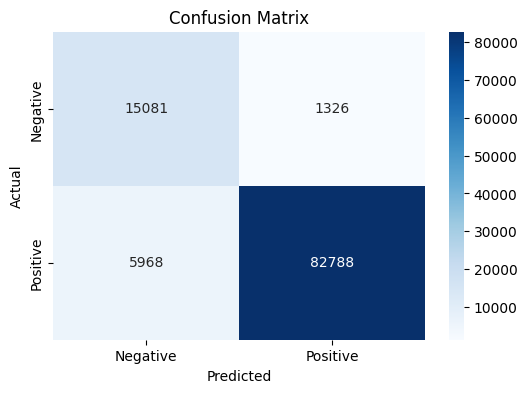

In [14]:
# Confusion Matrix:

y_pred = model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

#for evalution of model.

#Error:
# it predicted 5968 as negative but they were positvie reviews.
# it predicted 1326 as positive but they were negative.

In [16]:
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, model.predict_proba(X_test_tfidf)[:,1])
print("ROC-AUC Score:", roc)

# Classification report shows precision, recall, and F1-score for both classes

#The model correctly identified 92% of all actual negative reviews,
#but only 72% were truly negative.

# ROC-AUC score show the ability of model to distinguish between classes

              precision    recall  f1-score   support

           0       0.72      0.92      0.81     16407
           1       0.98      0.93      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.85      0.93      0.88    105163
weighted avg       0.94      0.93      0.93    105163

ROC-AUC Score: 0.9758791127513471


In [17]:
# Complaint Keywords:

#as the requirement is about to find the negative reviews (problems) so:

negative_reviews = X_test[y_pred == 0]

tfidf_neg = TfidfVectorizer(max_features=1000)
X_neg_tfidf = tfidf_neg.fit_transform(negative_reviews)

words = tfidf_neg.get_feature_names_out()
scores = X_neg_tfidf.mean(axis=0).A1

top_indices = scores.argsort()[-20:][::-1]

top_words = [(words[i], scores[i]) for i in top_indices]

for word, score in top_words:
    print(word, ":", score)


#Selected the reviews predicted as negative, then find the important words in that reviews
#through TDF get those words and calculate the avg(important score)
# Higher score = more imp complaints

like : 0.04107306964679476
taste : 0.04059350539331676
product : 0.03864292150877776
coffee : 0.0312892972818274
one : 0.02975944494127394
flavor : 0.028697706078317436
would : 0.02797061322524787
good : 0.025476466721695745
tea : 0.025041685156927413
food : 0.023945552656780677
dog : 0.02299344927207538
box : 0.02201719428739262
buy : 0.021403076319989382
get : 0.02040353829876097
bag : 0.01993645679908937
amazon : 0.019510506262716637
cup : 0.018161735208674472
time : 0.017850674305238363
even : 0.017783991498192552
much : 0.017647196632999504


In [ ]:
#Top complaint keywords (Justification):

#The keywords like “taste,” “flavor,” and “coffee” show that many complaints are related to poor taste.
#Words such as “product,” “box,” and “bag” suggest issues with packaging or condition of the items.
#Terms like “would” and “buy” indicate customer hesitation to repurchase the product.

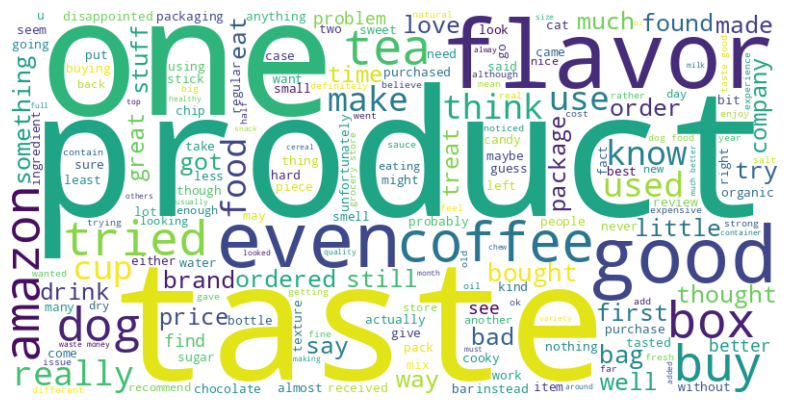

In [18]:
text_data = " ".join(negative_reviews)

wc = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.savefig("complaint_wordcloud.png")
plt.show()

# Combining all negative reviews into one text for visualization
#Bigger Text is appeared more frequently.

In [19]:
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

#saved the required files.

['tfidf_vectorizer.pkl']